## SDGE analysis

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from corrected_bill_calc import calculate_hourly_rates_with_consumption, calculate_total_bill
import time


In [11]:
metadata = pd.read_parquet('CA_Baseline_metadata_rescaled_twoincomes_puma20.parquet')

In [13]:
metadata.columns[0:100]

Index(['upgrade', 'weight', 'applicability', 'in.sqft',
       'in.representative_income', 'in.ahs_region', 'in.aiannh_area',
       'in.area_median_income', 'in.ashrae_iecc_climate_zone_2004',
       'in.ashrae_iecc_climate_zone_2004_2_a_split',
       'in.bathroom_spot_vent_hour', 'in.battery', 'in.bedrooms',
       'in.building_america_climate_zone', 'in.cec_climate_zone',
       'in.ceiling_fan', 'in.census_division', 'in.census_division_recs',
       'in.census_region', 'in.city', 'in.clothes_dryer',
       'in.clothes_dryer_usage_level', 'in.clothes_washer',
       'in.clothes_washer_presence', 'in.clothes_washer_usage_level',
       'in.cooking_range', 'in.cooking_range_usage_level',
       'in.cooling_setpoint', 'in.cooling_setpoint_has_offset',
       'in.cooling_setpoint_offset_magnitude',
       'in.cooling_setpoint_offset_period', 'in.corridor', 'in.county',
       'in.county_and_puma', 'in.county_name', 'in.dehumidifier',
       'in.dishwasher', 'in.dishwasher_usage_level'

In [ ]:
## bills with TOU weights for revenue neutrality
# baseline_bill_analysis.py - FINAL VERSION with corrected rates

import pandas as pd
import numpy as np
from pathlib import Path
from corrected_bill_calc import calculate_hourly_rates_with_consumption, calculate_total_bill
import time

# Original SDGE rates
RATE_SCENARIOS = {
    'DR': 'pre_fixed',
    'DR-F': 'post_fixed', 
    'TOU-DR': 'pre_fixed_tou',
    'TOU-DR-F': 'post_fixed_tou'
}

def normalize_income(income):
    income_map = {'Low': 'low', 'Medium': 'medium', 'High': 'high', 
                  'low': 'low', 'medium': 'medium', 'high': 'high'}
    return income_map.get(str(income).strip(), 'medium')

def load_metadata(metadata_file):
    df = pd.read_parquet(metadata_file).reset_index()
    metadata = {}
    for _, row in df.iterrows():
        metadata[str(row['building_id'])] = {
            'puma': row['puma20'],
            'income_category': normalize_income(row['income_category']),
            'scaling_factor': row['scaling_factor']
        }
    return metadata

def get_tou_period(hour, month):
    if 16 <= hour < 21:
        return 'peak'
    elif 6 <= hour < 16 or 21 <= hour < 22:
        return 'midpeak'
    else:
        return 'offpeak'

def calculate_bill_new_rate(hourly_load, rate_scenario, is_care):
    fixed_charge = rate_scenario['Fixed_CARE'] * 12 if is_care else rate_scenario['Fixed_NonCARE'] * 12
    energy_cost = 0
    for hour_idx, load in enumerate(hourly_load):
        month = (hour_idx // 730) + 1
        hour = hour_idx % 24
        season = 'summer' if 6 <= month <= 10 else 'winter'
        period = get_tou_period(hour, month)
        energy_cost += load * rate_scenario[f'{season}_{period}']
    return fixed_charge + energy_cost

def process_building(parquet_file, metadata, new_rate_scenarios):
    excel_file = 'retail_rates_data_SDGE.xlsx'
    
    df = pd.read_parquet(parquet_file)
    load_15min = df['out.electricity.total.energy_consumption'].values
    hourly_load_prescale = load_15min.reshape(-1, 4).sum(axis=1)
    
    building_id = int(parquet_file.stem.split('-')[0])
    puma = metadata[str(building_id)]['puma']
    income = metadata[str(building_id)]['income_category']
    scaling_factor = metadata[str(building_id)]['scaling_factor']
    is_care = (income == 'low')
    
    # Scale load
    hourly_load = hourly_load * scaling_factor
    
    results = {
        'building_id': building_id, 
        'income': income,
        'annual_kwh_prescaling': hourly_load_prescale.sum(),
        'annual_kwh_postscaling': hourly_load.sum(),
        'scaling_factor': scaling_factor
    }
    
    # Original SDGE rates
    for rate_code, scenario_name in RATE_SCENARIOS.items():
        hourly_rates = calculate_hourly_rates_with_consumption(
            puma, rate_code, hourly_load, excel_file, is_care
        )
        bill_info = calculate_total_bill(hourly_rates, hourly_load, income)
        results[f'{scenario_name}_bill'] = bill_info['total_bill']
    
    # New designed rates (all scenarios from corrected rate designer)
    # for _, rate_scenario in new_rate_scenarios.iterrows():
    #     scenario_name = rate_scenario['Scenario']
    #     bill = calculate_bill_new_rate(hourly_load, rate_scenario, is_care)
    #     results[f'new_{scenario_name}_bill'] = bill
    
    # return results

if __name__ == "__main__":
    print("Loading metadata...")
    metadata = load_metadata('CA_Baseline_metadata_rescaled_twoincomes_puma20.parquet')
    
    print("Loading corrected rate scenarios...")
    new_rate_scenarios = pd.read_csv('rate_scenarios_all_corrected.csv')
    print(f"Loaded {len(new_rate_scenarios)} rate scenarios")
    
    parquet_files = list(Path('./Baseline_SDGE').glob('*.parquet'))
    print(f"Processing {len(parquet_files)} buildings...")
    
    results = []
    start_time = time.time()
    
    for i, pq_file in enumerate(parquet_files):
        try:
            result = process_building(pq_file, metadata, new_rate_scenarios)
            results.append(result)
            
            if (i+1) % 500 == 0:
                elapsed = time.time() - start_time
                rate = (i+1) / elapsed
                remaining = (len(parquet_files) - (i+1)) / rate / 60
                print(f"{i+1}/{len(parquet_files)} done | {elapsed:.0f}s elapsed | ~{remaining:.1f}min remaining")
                
        except Exception as e:
            print(f"Error {pq_file.name}: {e}")
    
    print("\nCreating DataFrame...")
    df = pd.DataFrame(results)
    
    print(f"Saving {len(df)} buildings x {len(df.columns)} columns...")
    df.to_csv('bills_Feb6_originalrates.csv', index=False)
    
    print("\n" + "="*80)
    print("COMPLETED")
    print("="*80)
    print(f"Total time: {time.time() - start_time:.1f}s")
    print(f"Output: baseline_bills_final.csv")
    print(f"Columns: {len(df.columns)}")
    print(f"Sample:\n{df.head()}")

In [4]:
# baseline_bill_analysis.py - VECTORIZED VERSION

import pandas as pd
import numpy as np
from pathlib import Path
from corrected_bill_calc import calculate_hourly_rates_with_consumption, calculate_total_bill
import time

# Test with minimal scenarios
TEST_SCENARIOS = [
    'F0_WF0_ROE0',
    'F25_WF0_ROE0',
    'F0_WF1_ROE0',
    'F0_WF0_ROE0.5',
    'F25_WF1_ROE0.5'
]

def normalize_income(income):
    income_map = {'Low': 'low', 'Medium': 'medium', 'High': 'high', 
                  'low': 'low', 'medium': 'medium', 'high': 'high'}
    return income_map.get(str(income).strip(), 'medium')

def load_metadata(metadata_file):
    df = pd.read_parquet(metadata_file).reset_index()
    metadata = {}
    for _, row in df.iterrows():
        metadata[str(row['building_id'])] = {
            'puma': row['puma20'],
            'income_category': normalize_income(row['income_category']),
            'scaling_factor': row['scaling_factor']
        }
    return metadata

def calculate_all_bills_vectorized(hourly_load, rate_scenarios, is_care):
    """Calculate bills for ALL scenarios at once - much faster"""
    # Pre-calculate hour metadata once (8760 array)
    hours = np.arange(8760)
    months = (hours // 730) + 1
    hour_of_day = hours % 24
    is_summer = (months >= 6) & (months <= 10)
    is_peak = (hour_of_day >= 16) & (hour_of_day < 21)
    is_midpeak = ((hour_of_day >= 6) & (hour_of_day < 16)) | ((hour_of_day >= 21) & (hour_of_day < 22))
    
    bills = {}
    for _, scenario in rate_scenarios.iterrows():
        # Build 8760-hour rate array for this scenario
        rates = np.where(
            is_summer,
            np.where(is_peak, scenario['summer_peak'],
                    np.where(is_midpeak, scenario['summer_midpeak'], scenario['summer_offpeak'])),
            np.where(is_peak, scenario['winter_peak'],
                    np.where(is_midpeak, scenario['winter_midpeak'], scenario['winter_offpeak']))
        )
        
        # Calculate bill
        fixed = scenario['Fixed_CARE'] * 12 if is_care else scenario['Fixed_NonCARE'] * 12
        bills[scenario['Scenario']] = np.dot(hourly_load, rates) + fixed
    
    return bills

def process_building(parquet_file, metadata, new_rate_scenarios):
    df = pd.read_parquet(parquet_file)
    load_15min = df['out.electricity.total.energy_consumption'].values
    hourly_load = load_15min.reshape(-1, 4).sum(axis=1)
    
    building_id = int(parquet_file.stem.split('-')[0])
    puma = metadata[str(building_id)]['puma']
    income = metadata[str(building_id)]['income_category']
    scaling_factor = metadata[str(building_id)]['scaling_factor']
    is_care = (income == 'low')
    
    # Apply scaling
    hourly_load_scaled = hourly_load * scaling_factor
    
    results = {
        'building_id': building_id, 
        'income': income,
        'annual_kwh_prescaling': hourly_load.sum(),
        'scaling_factor': scaling_factor
    }
    
    # Calculate all bills at once (vectorized)
    all_bills = calculate_all_bills_vectorized(hourly_load_scaled, new_rate_scenarios, is_care)
    for scenario_name, bill in all_bills.items():
        results[f'new_{scenario_name}_bill'] = bill
    
    return results

if __name__ == "__main__":
    TEST_MODE = False
    N_BUILDINGS = 100 if TEST_MODE else None
    
    print("="*80)
    print(f"MODE: {'TEST' if TEST_MODE else 'FULL RUN'}")
    print("="*80)
    
    metadata = load_metadata('CA_Baseline_metadata_rescaled_twoincomes_puma20.parquet')
    
    all_rates = pd.read_csv('rate_scenarios_all_corrected.csv')
    new_rate_scenarios = all_rates[all_rates['Scenario'].isin(TEST_SCENARIOS)]
    print(f"\nRate scenarios: {len(new_rate_scenarios)}")
    
    parquet_files = list(Path('./Baseline_SDGE').glob('*.parquet'))
    if N_BUILDINGS:
        parquet_files = parquet_files[:N_BUILDINGS]
    
    print(f"Buildings to process: {len(parquet_files)}")
    
    results = []
    start_time = time.time()
    
    for i, pq_file in enumerate(parquet_files):
        try:
            result = process_building(pq_file, metadata, new_rate_scenarios)
            results.append(result)
            
            if (i+1) % 100 == 0:
                elapsed = time.time() - start_time
                rate = (i+1) / elapsed
                remaining = (len(parquet_files) - (i+1)) / rate / 60
                print(f"{i+1}/{len(parquet_files)} | {elapsed:.0f}s | ~{remaining:.1f}min left")
                
        except Exception as e:
            print(f"Error {pq_file.name}: {e}")
            import traceback
            traceback.print_exc()
            break
    
    df = pd.DataFrame(results)
    output_file = 'baseline_bills_TEST.csv' if TEST_MODE else 'baseline_bills_Feb6.csv'
    df.to_csv(output_file, index=False)
    
    print(f"\n{'='*80}")
    print(f"Saved: {output_file}")
    print(f"Time: {time.time() - start_time:.1f}s")
    print(f"Buildings: {len(df)} | Columns: {len(df.columns)}")

MODE: FULL RUN

Rate scenarios: 5
Buildings to process: 4317
100/4317 | 160s | ~112.1min left
200/4317 | 298s | ~102.4min left
300/4317 | 447s | ~99.8min left
400/4317 | 589s | ~96.1min left
500/4317 | 759s | ~96.6min left
600/4317 | 907s | ~93.7min left
700/4317 | 1048s | ~90.3min left
800/4317 | 1196s | ~87.6min left
900/4317 | 1346s | ~85.2min left
1000/4317 | 1490s | ~82.4min left
1100/4317 | 1633s | ~79.6min left
1200/4317 | 1785s | ~77.3min left
1300/4317 | 1922s | ~74.3min left
1400/4317 | 2066s | ~71.7min left
1500/4317 | 2214s | ~69.3min left
1600/4317 | 2365s | ~66.9min left
1700/4317 | 2510s | ~64.4min left
1800/4317 | 2677s | ~62.4min left
1900/4317 | 2841s | ~60.2min left
2000/4317 | 3006s | ~58.0min left
2100/4317 | 3160s | ~55.6min left
2200/4317 | 3310s | ~53.1min left
2300/4317 | 3460s | ~50.6min left
2400/4317 | 3602s | ~48.0min left
2500/4317 | 3754s | ~45.5min left
2600/4317 | 3895s | ~42.9min left
2700/4317 | 4042s | ~40.3min left
2800/4317 | 4184s | ~37.8min left


In [8]:
df = pd.read_csv('baseline_bills_Feb6.csv')
df.columns

Index(['building_id', 'income', 'annual_kwh_prescaling', 'scaling_factor',
       'new_F0_WF0_ROE0_bill', 'new_F0_WF0_ROE0.5_bill',
       'new_F0_WF1_ROE0_bill', 'new_F25_WF0_ROE0_bill',
       'new_F25_WF1_ROE0.5_bill'],
      dtype='object')

In [6]:
df = pd.read_csv('baseline_bills_Feb6.csv')

# Bottom 25% vs Top 25%
very_low = df[df['annual_kwh'] < df['annual_kwh'].quantile(0.25)]
very_high = df[df['annual_kwh'] > df['annual_kwh'].quantile(0.75)]

print(f"Very LOW users (bottom 25%, <{df['annual_kwh'].quantile(0.25):.0f} kWh):")
change_low = (very_low['new_F25_WF0_ROE0_bill'] - very_low['new_F0_WF0_ROE0_bill']).mean()
print(f"  F0→F25 change: ${change_low:.2f} {'✓ CORRECT' if change_low > 0 else '✗ WRONG'}")

print(f"\nVery HIGH users (top 25%, >{df['annual_kwh'].quantile(0.75):.0f} kWh):")
change_high = (very_high['new_F25_WF0_ROE0_bill'] - very_high['new_F0_WF0_ROE0_bill']).mean()
print(f"  F0→F25 change: ${change_high:.2f} {'✓ CORRECT' if change_high < 0 else '✗ WRONG'}")

print(f"\nBreak-even point: ~4,368 kWh/year")


KeyError: 'annual_kwh'

In [ ]:
import pandas as pd

rates = pd.read_csv('rate_scenarios_all_corrected.csv')

# Compare F0 and F25 with ROE0
scenarios = rates[rates['Scenario'].isin(['F0_WF0_ROE0', 'F25_WF0_ROE0'])]

print("Rate Design Check:")
for _, row in scenarios.iterrows():
    print(f"\n{row['Scenario']}:")
    print(f"  Fixed CARE:     ${row['Fixed_CARE']:.2f}/month")
    print(f"  Fixed Non-CARE: ${row['Fixed_NonCARE']:.2f}/month")
    print(f"  Vol Avg:        ${row['Vol_Avg']:.4f}/kWh")
    print(f"  Target Revenue: ${row['Total_Revenue']/1e9:.4f}B")


In [ ]:
# baseline_bill_analysis.py

import pandas as pd
import numpy as np
from pathlib import Path
from corrected_bill_calc import calculate_hourly_rates_with_consumption, calculate_total_bill
import time

# Original SDGE rates
RATE_SCENARIOS = {
    'DR': 'pre_fixed',
    'DR-F': 'post_fixed', 
    'TOU-DR': 'pre_fixed_tou',
    'TOU-DR-F': 'post_fixed_tou'
}

# 24 new scenarios from corrected rate designer
KEY_NEW_SCENARIOS = [f'F{f}_WF{w}_ROE{r}' 
                     for f in [0, 25, 50, 75] 
                     for w in [0, 1] 
                     for r in [0, 0.5, 1.0, 1.5]]

def normalize_income(income):
    income_map = {'Low': 'low', 'Medium': 'medium', 'High': 'high', 
                  'low': 'low', 'medium': 'medium', 'high': 'high'}
    return income_map.get(str(income).strip(), 'medium')

def load_metadata(metadata_file):
    df = pd.read_parquet(metadata_file).reset_index()
    metadata = {}
    for _, row in df.iterrows():
        metadata[str(row['building_id'])] = {
            'puma': row['puma20'],
            'income_category': normalize_income(row['income_category']),
            'scaling_factor': row['scaling_factor']
        }
    return metadata

def get_tou_period(hour, month):
    if 16 <= hour < 21:
        return 'peak'
    elif 6 <= hour < 16 or 21 <= hour < 22:
        return 'midpeak'
    else:
        return 'offpeak'

def calculate_bill_new_rate(hourly_load, rate_scenario, is_care):
    fixed_charge = rate_scenario['Fixed_CARE'] * 12 if is_care else rate_scenario['Fixed_NonCARE'] * 12
    energy_cost = 0
    for hour_idx, load in enumerate(hourly_load):
        month = (hour_idx // 730) + 1
        hour = hour_idx % 24
        season = 'summer' if 6 <= month <= 10 else 'winter'
        period = get_tou_period(hour, month)
        energy_cost += load * rate_scenario[f'{season}_{period}']
    return fixed_charge + energy_cost

def process_building(parquet_file, metadata, new_rate_scenarios):
    excel_file = 'retail_rates_data_SDGE.xlsx'
    
    df = pd.read_parquet(parquet_file)
    load_15min = df['out.electricity.total.energy_consumption'].values
    hourly_load = load_15min.reshape(-1, 4).sum(axis=1)
    
    building_id = int(parquet_file.stem.split('-')[0])
    puma = metadata[str(building_id)]['puma']
    income = metadata[str(building_id)]['income_category']
    scaling_factor = metadata[str(building_id)]['scaling_factor']
    is_care = (income == 'low')
    
    # Scale load
    hourly_load = hourly_load * scaling_factor
    
    results = {
        'building_id': building_id, 
        'income': income,
        'annual_kwh': hourly_load.sum()
    }
    
    # Original SDGE rates
    for rate_code, scenario_name in RATE_SCENARIOS.items():
        hourly_rates = calculate_hourly_rates_with_consumption(
            puma, rate_code, hourly_load, excel_file, is_care
        )
        bill_info = calculate_total_bill(hourly_rates, hourly_load, income)
        results[f'{scenario_name}_bill'] = bill_info['total_bill']
    
    # New designed rates
    for _, rate_scenario in new_rate_scenarios.iterrows():
        scenario_name = rate_scenario['Scenario']
        bill = calculate_bill_new_rate(hourly_load, rate_scenario, is_care)
        results[f'new_{scenario_name}_bill'] = bill
    
    return results

if __name__ == "__main__":
    metadata = load_metadata('CA_Baseline_metadata_rescaled_twoincomes_puma20.parquet')
    
    # Load corrected rate scenarios
    all_rates = pd.read_csv('rate_scenarios_all_corrected.csv')
    new_rate_scenarios = all_rates[all_rates['Scenario'].isin(KEY_NEW_SCENARIOS)]
    print(f"Testing {len(new_rate_scenarios)} new rate scenarios")
    
    parquet_files = list(Path('./Baseline_SDGE').glob('*.parquet'))
    print(f"Processing {len(parquet_files)} buildings")
    
    results = []
    start_time = time.time()
    
    for i, pq_file in enumerate(parquet_files):
        try:
            result = process_building(pq_file, metadata, new_rate_scenarios)
            results.append(result)
            if (i+1) % 100 == 0:
                elapsed = time.time() - start_time
                print(f"{i+1}/{len(parquet_files)} done in {elapsed:.1f}s")
        except Exception as e:
            print(f"Error {pq_file.name}: {e}")
            import traceback
            traceback.print_exc()
            break
    
    df = pd.DataFrame(results)
    df.to_csv('baseline_bills_all_scenarios_corrected.csv', index=False)
    print(f"\nSaved {len(df)} buildings x {len(df.columns)} columns")
    print(df.head())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('baseline_bills_Feb5.csv')

# Boxplot comparison
fig, ax = plt.subplots(figsize=(10, 6))
bill_data = []
labels = []
for col, rate in [('pre_fixed_tou_bill', 'TOU-DR1'),
                  ('post_fixed_tou_bill', 'TOU-DR1-F')]:
    bill_data.append(df[col].values)
    labels.append(rate)

positions = np.arange(len(labels))
bp = ax.boxplot(bill_data, positions=positions, widths=0.6, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

ax.set_xticklabels(labels)
ax.set_ylabel('Annual Bill ($)')
ax.set_title('Bill Distribution by Rate')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()


In [ ]:
df.columns

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('baseline_bills_Feb5.csv')

# Scenario groups with combined wildfire + ROE bucket
scenario_groups = {
    'Original SDGE Rates': [
        ('pre_fixed_tou_bill', 'TOU-DR1'),
        ('post_fixed_tou_bill', 'TOU-DR1-F')
    ],
    'Fixed Charge Progression\n(No policy changes)': [
        ('new_F0_WF0_ROE0_bill', 'F0%'),
        ('new_F25_WF0_ROE0_bill', 'F25%'),
    ],
    'Policy Changes\n(Wildfire + ROE reductions)': [
        ('new_F0_WF1_ROE0_bill', 'WF only'),
        ('new_F0_WF0_ROE0.5_bill', 'ROE only'),
        ('new_F0_WF1_ROE0.5_bill', 'WF+ROE')
    ],
    'Combined: 25% Fixed + Policies': [
        ('new_F25_WF1_ROE0.5_bill', 'F25 + both'),
    ]
}

# Find global min and max
all_cols = []
for scenarios in scenario_groups.values():
    for col, _ in scenarios:
        if col in df.columns:
            all_cols.append(col)

global_min = df[all_cols].min().min()
global_max = df[all_cols].max().max()

# Add padding
y_range = global_max - global_min
y_min = global_min - 0.05 * y_range
y_max = global_max + 0.05 * y_range

# Create plot (2x3 with last empty)
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, (group_name, scenarios) in enumerate(scenario_groups.items()):
    ax = axes[idx]
    
    bill_data = []
    labels = []
    
    for col, label in scenarios:
        if col in df.columns:
            bill_data.append(df[col].values)
            labels.append(label)
    
    positions = np.arange(len(labels))
    bp = ax.boxplot(bill_data, positions=positions, widths=0.6, patch_artist=True)
    
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Annual Bill ($)')
    ax.set_title(group_name, fontsize=10, fontweight='bold')
    ax.set_ylim(y_min, y_max)
    ax.grid(axis='y', alpha=0.3)

# Remove last empty subplot
axes[-1].remove()

plt.tight_layout()
plt.savefig('all_scenarios_comparison.png', dpi=150, bbox_inches='tight')
print("Saved: all_scenarios_comparison.png")
print(f"Y-axis range: ${y_min:.0f} to ${y_max:.0f}")

In [ ]:
df.head(5)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('baseline_bills_Feb5.csv')

# Check if income is already categorical or numeric
if df['income'].dtype == 'object':
    # Already categorical (low/medium/high)
    income_categories = df['income'].unique()
else:
    # Numeric - create categories
    df['income'] = pd.cut(df['income'], 
                          bins=[0, 50000, 100000, np.inf],
                          labels=['low', 'medium', 'high'])

# Calculate percentage changes
df['pct_change_DR'] = 100 * (df['post_fixed_bill'] - df['pre_fixed_bill']) / df['pre_fixed_bill']
df['pct_change_TOU'] = 100 * (df['post_fixed_tou_bill'] - df['pre_fixed_tou_bill']) / df['pre_fixed_tou_bill']

# Boxplot by income
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in zip(axes, 
                          ['pct_change_DR', 'pct_change_TOU'],
                          ['DR → DR-F', 'TOU-DR1 → TOU-DR1-F']):
    
    data = [df[df['income'] == inc][col].dropna().values 
            for inc in ['low', 'medium', 'high']]
    positions = [1, 2, 3]
    
    bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.set_xlabel('Income Level')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{title}')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pct_change_by_income.png', dpi=150)

# Summary stats
print("\nPercentage Change Summary:")
for income in ['low', 'medium', 'high']:
    df_inc = df[df['income'] == income]
    print(f"\n{income.upper()} Income (n={len(df_inc)}):")
    print(f"  DR → DR-F:        {df_inc['pct_change_DR'].mean():.1f}% "
          f"(median: {df_inc['pct_change_DR'].median():.1f}%)")
    print(f"  TOU-DR1 → TOU-F:  {df_inc['pct_change_TOU'].mean():.1f}% "
          f"(median: {df_inc['pct_change_TOU'].median():.1f}%)")

print("\nSaved: pct_change_by_income.png")

In [ ]:
df = pd.read_csv('baseline_bills_all_scenarios_corrected.csv')
df.columns

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('baseline_bills_all_scenarios_corrected.csv')

baseline_col = 'pre_fixed_tou_bill'

# Match actual column names exactly
comparisons = {
    'F25':        'new_F25_WF0_ROE0_bill',
    'F50':        'new_F50_WF0_ROE0_bill',
    'F75':        'new_F75_WF0_ROE0_bill',
    'Remove WF':  'new_F0_WF1_ROE0_bill',
    'ROE-1.5':    'new_F0_WF0_ROE1.5_bill',
    'F50+Both':   'new_F50_WF1_ROE1.5_bill',
    'F75+All':    'new_F75_WF1_ROE1.5_bill'
}

# Calculate percentage and dollar changes
for label, col in comparisons.items():
    df[f'pct_{label}'] = 100 * (df[col] - df[baseline_col]) / df[baseline_col]
    df[f'dollar_{label}'] = df[col] - df[baseline_col]

fig, axes = plt.subplots(3, 3, figsize=(20, 16))

# Row 1: Fixed charge progression (% change by income)
for ax, label in zip(axes[0], ['F25', 'F50', 'F75']):
    data = [df[df['income'] == inc][f'pct_{label}'].values for inc in ['low', 'medium', 'high']]
    bp = ax.boxplot(data, positions=[1, 2, 3], widths=0.5, patch_artist=True, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor('lightcoral')
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'Fixed Charge {label}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# Row 2: Policy changes (% change by income)
for ax, label in zip(axes[1], ['Remove WF', 'ROE-1.5', 'F50+Both']):
    data = [df[df['income'] == inc][f'pct_{label}'].values for inc in ['low', 'medium', 'high']]
    bp = ax.boxplot(data, positions=[1, 2, 3], widths=0.5, patch_artist=True, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor('lightgreen')
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{label}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# Row 3: Absolute dollar changes by usage
for ax, label in zip(axes[2], ['F50', 'Remove WF', 'F75+All']):
    ax.scatter(df['annual_kwh'], df[f'dollar_{label}'], alpha=0.5, s=20)
    ax.axhline(0, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel('Annual Usage (kWh)')
    ax.set_ylabel('Bill Change ($)')
    ax.set_title(f'{label} - Dollar Change vs Usage', fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scenario_changes_comprehensive.png', dpi=150, bbox_inches='tight')

# Summary stats
print("\n=== PERCENTAGE CHANGE SUMMARY BY INCOME (vs TOU-DR) ===\n")
for label in comparisons.keys():
    print(f"\n{label}:")
    for income in ['low', 'medium', 'high']:
        df_inc = df[df['income'] == income]
        print(f"  {income.capitalize():8s} - Mean: {df_inc[f'pct_{label}'].mean():6.1f}% (${df_inc[f'dollar_{label}'].mean():6.0f}) | "
              f"Median: {df_inc[f'pct_{label}'].median():6.1f}% (${df_inc[f'dollar_{label}'].median():6.0f})")

In [ ]:
df['pct_vs_current'] = 100 * (df['new_F50_WF0_ROE0_bill'] - df['pre_fixed_tou_bill']) / df['pre_fixed_tou_bill']

print("F50% vs Current TOU-DR1:")
print(df[['annual_kwh', 'pct_vs_current']].describe())

# Check the baseline rates
rates = pd.read_csv('rate_scenarios_all.csv')
print("\nRate comparison:")
print(rates[rates['Scenario'].isin(['F0_WF0_ROE0', 'F50_WF0_ROE0'])][['Scenario', 'Vol_Avg', 'Fixed_CARE', 'Fixed_NonCARE']])


In [ ]:
import pandas as pd

df = pd.read_csv('baseline_bills_all_scenarios_corrected.csv')

# Calculate total revenue collected under each scenario
total_customers_in_sample = len(df)
scaling_factor = 1_323_612 / total_customers_in_sample

scenarios_to_check = ['new_F0_WF0_ROE0_bill', 'new_F25_WF0_ROE0_bill', 
                      'new_F50_WF0_ROE0_bill', 'new_F75_WF0_ROE0_bill']

print("Revenue Neutrality Check (scaled to full SDGE):\n")
for scenario in scenarios_to_check:
    total_revenue = df[scenario].sum() * scaling_factor
    print(f"{scenario:30s}: ${total_revenue/1e9:.3f}B")

# Compare to designed target
rates = pd.read_csv('rate_scenarios_all_corrected.csv')
f0_row = rates[rates['Scenario'] == 'F0_WF0_ROE0'].iloc[0]

# Calculate what revenue SHOULD be
RESIDENTIAL_SALES_KWH = 4_810_000_000
baseline_avg = (f0_row['summer_peak'] + f0_row['summer_offpeak'] + 
                f0_row['winter_peak'] + f0_row['winter_offpeak']) / 4
designed_revenue = baseline_avg * RESIDENTIAL_SALES_KWH

print(f"\nDesigned revenue target: ${designed_revenue/1e9:.3f}B")
print("\nAll F0/F25/F50/F75 scenarios should collect the same total revenue")
print("If they don't, we have a calculation bug")

In [ ]:
# Debug: Calculate manually for one building
df = pd.read_csv('baseline_bills_all_scenarios_corrected.csv')
rates = pd.read_csv('rate_scenarios_all_corrected.csv')

# Get first building
first_building = df.iloc[0]
f0_rate = rates[rates['Scenario'] == 'F0_WF0_ROE0'].iloc[0]

print("Building 1:")
print(f"  Annual kWh: {first_building['annual_kwh']:.0f}")
print(f"  F0 bill calculated: ${first_building['new_F0_WF0_ROE0_bill']:.2f}")

# Manual calculation
avg_volumetric = (f0_rate['summer_peak'] + f0_rate['summer_offpeak'] + 
                  f0_rate['winter_peak'] + f0_rate['winter_offpeak']) / 4
manual_bill = first_building['annual_kwh'] * avg_volumetric
print(f"  Manual calculation (avg rate): ${manual_bill:.2f}")
print(f"\n  Ratio: {first_building['new_F0_WF0_ROE0_bill'] / manual_bill:.2f}x")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('baseline_bills_all_scenarios.csv')

# Calculate bill changes
df['dollar_change_DR'] = df['post_fixed_bill'] - df['pre_fixed_bill']
df['dollar_change_TOU'] = df['post_fixed_tou_bill'] - df['pre_fixed_tou_bill']
df['pct_change_DR'] = 100 * df['dollar_change_DR'] / df['pre_fixed_bill']
df['pct_change_TOU'] = 100 * df['dollar_change_TOU'] / df['pre_fixed_tou_bill']

# Scatter plot: usage vs change
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dollar change
for ax, col, title in zip(axes[0], 
                          ['dollar_change_DR', 'dollar_change_TOU'],
                          ['DR → DR-F', 'TOU-DR1 → TOU-DR1-F']):
    for income, color in [('low', 'blue'), ('medium', 'green'), ('high', 'red')]:
        df_inc = df[df['income'] == income]
        ax.scatter(df_inc['annual_kwh'], df_inc[col], alpha=0.6, 
                  label=income.capitalize(), color=color, s=30)
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Annual Usage (kWh)')
    ax.set_ylabel('Bill Change ($)')
    ax.set_title(f'{title} - Dollar Change')
    ax.legend()
    ax.grid(alpha=0.3)

# Percentage change
for ax, col, title in zip(axes[1], 
                          ['pct_change_DR', 'pct_change_TOU'],
                          ['DR → DR-F', 'TOU-DR1 → TOU-DR1-F']):
    for income, color in [('low', 'blue'), ('medium', 'green'), ('high', 'red')]:
        df_inc = df[df['income'] == income]
        ax.scatter(df_inc['annual_kwh'], df_inc[col], alpha=0.6, 
                  label=income.capitalize(), color=color, s=30)
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Annual Usage (kWh)')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{title} - Percent Change')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('change_by_usage.png', dpi=150)

print("\nSaved: change_by_usage.png")
print("\nExpected pattern: Low usage → increase, High usage → decrease")

In [ ]:
# final_analysis.py - 5 Scenario Comparison (TOU-DR as baseline)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('baseline_bills_Feb5.csv')
scaling_factor = 1_323_612 / len(df)

# Define 5 scenarios with TOU-DR as baseline
SCENARIOS = {
    1: {'col': 'pre_fixed_tou_bill', 'label': 'TOU-DR\n(Baseline)', 'color': 'lightgray'},
    2: {'col': 'post_fixed_tou_bill', 'label': 'TOU-DR-F\n($6/$24/mo)', 'color': 'skyblue'},
    3: {'col': 'new_F25_WF0_ROE0_bill', 'label': 'F25%', 'color': 'steelblue'},
    4: {'col': 'new_F0_WF1_ROE0_bill', 'label': 'Remove\nWildfire', 'color': 'lightcoral'},
    5: {'col': 'new_F0_WF1_ROE0.5_bill', 'label': 'WF +\nROE-0.5', 'color': 'darkgreen'}
}

baseline_col = SCENARIOS[1]['col']
baseline_mean = df[baseline_col].mean()

# Calculate changes from TOU-DR baseline for scenarios 2-5
for i in range(2, 6):
    col = SCENARIOS[i]['col']
    df[f'pct_change_{i}'] = 100 * (df[col] - df[baseline_col]) / df[baseline_col]
    df[f'dollar_change_{i}'] = df[col] - df[baseline_col]

# # ============================================================================
# # FIGURE 1: Box plot of all 5 scenarios
# # ============================================================================

# fig, ax = plt.subplots(figsize=(12, 7))

# bill_data = [df[SCENARIOS[i]['col']].values for i in range(1, 6)]
# labels = [SCENARIOS[i]['label'] for i in range(1, 6)]
# colors = [SCENARIOS[i]['color'] for i in range(1, 6)]

# positions = np.arange(len(labels))
# bp = ax.boxplot(bill_data, positions=positions, widths=0.6, patch_artist=True)

# for patch, color in zip(bp['boxes'], colors):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.7)

# ax.set_xticks(positions)
# ax.set_xticklabels(labels, fontsize=11)
# ax.set_ylabel('Annual Bill ($)', fontsize=12)
# ax.set_title('Bill Distribution Across All Scenarios (n=4000 buildings)', 
#              fontsize=14, fontweight='bold')
# ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.savefig('fig1_all_scenarios_boxplot.png', dpi=150, bbox_inches='tight')
# print("Saved: fig1_all_scenarios_boxplot.png")

# Replace FIGURE 1 section:

# ============================================================================
# FIGURE 1: Box plot - ZOOMED to show differences
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

bill_data = [df[SCENARIOS[i]['col']].values for i in range(1, 6)]
labels = [SCENARIOS[i]['label'] for i in range(1, 6)]
colors = [SCENARIOS[i]['color'] for i in range(1, 6)]

positions = np.arange(len(labels))
bp = ax.boxplot(bill_data, positions=positions, widths=0.6, patch_artist=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# ZOOM IN on the interquartile range
all_data = np.concatenate(bill_data)
q1, q3 = np.percentile(all_data, [25, 75])
iqr = q3 - q1
y_min = max(0, q1 - 1.5*iqr)
y_max = q3 + 1.5*iqr

ax.set_ylim(y_min, y_max)

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Annual Bill ($)', fontsize=12)
ax.set_title('Bill Distribution Across All Scenarios (n=4000 buildings)\nZoomed to show differences', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add median values as text
for i, data in enumerate(bill_data):
    median = np.median(data)
    ax.text(i, median, f'${median:.0f}', 
           ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_all_scenarios_boxplot.png', dpi=150, bbox_inches='tight')
print("Saved: fig1_all_scenarios_boxplot.png")
# ============================================================================
# FIGURE 2: % Bill changes by income (4 subplots - scenarios 2-5)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, scenario_num in enumerate(range(2, 6)):
    ax = axes[idx]
    col = f'pct_change_{scenario_num}'
    
    data = [df[df['income'] == inc][col].values for inc in ['low', 'medium', 'high']]
    positions = [1, 2, 3]
    
    bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(SCENARIOS[scenario_num]['color'])
        patch.set_alpha(0.7)
    
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.set_xlabel('Income Level')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{SCENARIOS[scenario_num]["label"]} vs TOU-DR Baseline', 
                 fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean values as text
    for i, income in enumerate(['low', 'medium', 'high']):
        mean_val = df[df['income'] == income][col].mean()
        ax.text(i+1, ax.get_ylim()[1]*0.9, f'{mean_val:.1f}%', 
               ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_pct_change_by_income.png', dpi=150, bbox_inches='tight')
print("Saved: fig2_pct_change_by_income.png")

# ============================================================================
# FIGURE 3: % Bill changes by consumption (4 subplots)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, scenario_num in enumerate(range(2, 6)):
    ax = axes[idx]
    col = f'pct_change_{scenario_num}'
    
    # Color by income
    for income, color, marker in [('low', 'blue', 'o'), 
                                   ('medium', 'green', 's'), 
                                   ('high', 'red', '^')]:
        df_inc = df[df['income'] == income]
        ax.scatter(df_inc['annual_kwh'], df_inc[col], 
                  alpha=0.5, s=15, c=color, marker=marker, label=income.capitalize())
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Annual Usage (kWh)')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{SCENARIOS[scenario_num]["label"]} vs TOU-DR Baseline', 
                 fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_pct_change_by_consumption.png', dpi=150, bbox_inches='tight')
print("Saved: fig3_pct_change_by_consumption.png")

# Replace FIGURE 4 section only:

# ============================================================================
# FIGURE 4: Revenue requirement across scenarios (CORRECTED SCALE)
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Calculate actual revenues
revenues_calculated = []
for i in range(1, 6):
    col = SCENARIOS[i]['col']
    total_rev = df[col].sum() * scaling_factor / 1e9
    revenues_calculated.append(total_rev)

# Scale to actual SDGE residential revenue
TARGET_REVENUE = 1.562  # $1.562B actual
baseline_calculated = revenues_calculated[0]
scaling_correction = TARGET_REVENUE / baseline_calculated

revenues_corrected = [rev * scaling_correction for rev in revenues_calculated]

bars = ax.bar(range(5), revenues_corrected, color=[SCENARIOS[i]['color'] for i in range(1, 6)],
              alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xticks(range(5))
ax.set_xticklabels([SCENARIOS[i]['label'] for i in range(1, 6)], fontsize=11)
ax.set_ylabel('Total Residential Revenue ($B)', fontsize=12)
ax.set_title('Revenue Requirement Across Scenarios\n(Scaled to actual SDGE residential: $1.562B)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, rev) in enumerate(zip(bars, revenues_corrected)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${rev:.2f}B',
            ha='center', va='bottom', fontsize=10, fontweight='bold')



plt.tight_layout()
plt.savefig('fig4_revenue_requirements.png', dpi=150, bbox_inches='tight')
print("Saved: fig4_revenue_requirements.png")
# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS (TOU-DR as Baseline)")
print("="*80)

print("\n1. MEAN ANNUAL BILLS:")
for i in range(1, 6):
    col = SCENARIOS[i]['col']
    mean_bill = df[col].mean()
    pct_vs_baseline = (mean_bill - baseline_mean) / baseline_mean * 100 if i > 1 else 0
    print(f"   {SCENARIOS[i]['label']:20s}: ${mean_bill:6.0f} ({pct_vs_baseline:+6.1f}%)")

print("\n2. TOTAL REVENUE (scaled to full SDGE):")
for i in range(1, 6):
    col = SCENARIOS[i]['col']
    total_rev = df[col].sum() * scaling_factor / 1e9
    print(f"   {SCENARIOS[i]['label']:20s}: ${total_rev:.3f}B")

print("\n3. BILL CHANGES BY INCOME (mean % change from TOU-DR baseline):")
for scenario_num in range(2, 6):
    print(f"\n   {SCENARIOS[scenario_num]['label']}:")
    for income in ['low', 'medium', 'high']:
        col = f'pct_change_{scenario_num}'
        mean_pct = df[df['income'] == income][col].mean()
        median_pct = df[df['income'] == income][col].median()
        print(f"      {income.capitalize():8s}: Mean {mean_pct:+6.1f}%  |  Median {median_pct:+6.1f}%")

print("\n" + "="*80)

In [ ]:
# final_analysis.py - 5 Scenario Comparison (TOU-DR as baseline) - NO OUTLIERS

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('baseline_bills_Feb5.csv')
scaling_factor = 1_323_612 / len(df)

# Define 5 scenarios with TOU-DR as baseline
SCENARIOS = {
    1: {'col': 'pre_fixed_tou_bill', 'label': 'TOU-DR\n(Baseline)', 'color': 'lightgray'},
    2: {'col': 'post_fixed_tou_bill', 'label': 'TOU-DR-F\n($6/$24/mo)', 'color': 'skyblue'},
    3: {'col': 'new_F25_WF0_ROE0_bill', 'label': 'F25%', 'color': 'steelblue'},
    4: {'col': 'new_F0_WF1_ROE0_bill', 'label': 'Remove\nWildfire', 'color': 'lightcoral'},
    5: {'col': 'new_F0_WF0_ROE0.5_bill', 'label': 'WF +\nROE-0.5', 'color': 'darkgreen'}
}

baseline_col = SCENARIOS[1]['col']
baseline_mean = df[baseline_col].mean()

# Calculate changes from TOU-DR baseline for scenarios 2-5
for i in range(2, 6):
    col = SCENARIOS[i]['col']
    df[f'pct_change_{i}'] = 100 * (df[col] - df[baseline_col]) / df[baseline_col]
    df[f'dollar_change_{i}'] = df[col] - df[baseline_col]

# ============================================================================
# FIGURE 1: Box plot - NO OUTLIERS
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

bill_data = [df[SCENARIOS[i]['col']].values for i in range(1, 6)]
labels = [SCENARIOS[i]['label'] for i in range(1, 6)]
colors = [SCENARIOS[i]['color'] for i in range(1, 6)]

positions = np.arange(len(labels))
bp = ax.boxplot(bill_data, positions=positions, widths=0.6, patch_artist=True,
                showfliers=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Annual Bill ($)', fontsize=12)
ax.set_title('Bill Distribution (Interquartile Range)\nn=4000 buildings', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add median values
for i, data in enumerate(bill_data):
    median = np.median(data)
    ax.text(i, median, f'${median:.0f}', 
           ha='center', va='bottom', fontsize=9, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('fig1_all_scenarios_boxplot.png', dpi=150, bbox_inches='tight')
print("Saved: fig1_all_scenarios_boxplot.png")

# ============================================================================
# FIGURE 2: % Bill changes by income - NO OUTLIERS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, scenario_num in enumerate(range(2, 6)):
    ax = axes[idx]
    col = f'pct_change_{scenario_num}'
    
    data = [df[df['income'] == inc][col].values for inc in ['low', 'medium', 'high']]
    positions = [1, 2, 3]
    
    bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True,
                    showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(SCENARIOS[scenario_num]['color'])
        patch.set_alpha(0.7)
    
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.set_xlabel('Income Level')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{SCENARIOS[scenario_num]["label"]} vs TOU-DR Baseline', 
                 fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add median values
    for i, income in enumerate(['low', 'medium', 'high']):
        median_val = df[df['income'] == income][col].median()
        ax.text(i+1, median_val, f'{median_val:.1f}%', 
               ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_pct_change_by_income.png', dpi=150, bbox_inches='tight')
print("Saved: fig2_pct_change_by_income.png")

# ============================================================================
# FIGURE 3: % Bill changes by consumption - NO OUTLIERS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, scenario_num in enumerate(range(2, 6)):
    ax = axes[idx]
    col = f'pct_change_{scenario_num}'
    
    # Remove outliers from scatter (keep only IQR range)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_filtered = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    # Color by income
    for income, color, marker in [('low', 'blue', 'o'), 
                                   ('medium', 'green', 's'), 
                                   ('high', 'red', '^')]:
        df_inc = df_filtered[df_filtered['income'] == income]
        ax.scatter(df_inc['annual_kwh'], df_inc[col], 
                  alpha=0.5, s=15, c=color, marker=marker, label=income.capitalize())
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Annual Usage (kWh)')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{SCENARIOS[scenario_num]["label"]} vs TOU-DR Baseline', 
                 fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_pct_change_by_consumption.png', dpi=150, bbox_inches='tight')
print("Saved: fig3_pct_change_by_consumption.png")

# ============================================================================
# FIGURE 4: Revenue requirement - CORRECTED SCALE
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

revenues_calculated = []
for i in range(1, 6):
    col = SCENARIOS[i]['col']
    total_rev = df[col].sum() * scaling_factor / 1e9
    revenues_calculated.append(total_rev)

TARGET_REVENUE = 1.562
baseline_calculated = revenues_calculated[0]
scaling_correction = TARGET_REVENUE / baseline_calculated
revenues_corrected = [rev * scaling_correction for rev in revenues_calculated]

bars = ax.bar(range(5), revenues_corrected, color=[SCENARIOS[i]['color'] for i in range(1, 6)],
              alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xticks(range(5))
ax.set_xticklabels([SCENARIOS[i]['label'] for i in range(1, 6)], fontsize=11)
ax.set_ylabel('Total Residential Revenue ($B)', fontsize=12)
ax.set_title('Revenue Requirement Across Scenarios\n(Scaled to actual SDGE residential: $1.562B)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, (bar, rev) in enumerate(zip(bars, revenues_corrected)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${rev:.2f}B',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_revenue_requirements.png', dpi=150, bbox_inches='tight')
print("Saved: fig4_revenue_requirements.png")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS (TOU-DR as Baseline)")
print("="*80)

print("\n1. MEAN ANNUAL BILLS:")
for i in range(1, 6):
    col = SCENARIOS[i]['col']
    mean_bill = df[col].mean()
    median_bill = df[col].median()
    pct_vs_baseline = (mean_bill - baseline_mean) / baseline_mean * 100 if i > 1 else 0
    print(f"   {SCENARIOS[i]['label']:20s}: Mean ${mean_bill:6.0f} | Median ${median_bill:6.0f} ({pct_vs_baseline:+6.1f}%)")

print("\n2. TOTAL REVENUE (scaled to actual SDGE residential):")
for i in range(1, 6):
    rev = revenues_corrected[i-1]
    pct_change = ((rev - revenues_corrected[0]) / revenues_corrected[0] * 100) if i > 1 else 0
    print(f"   {SCENARIOS[i]['label']:20s}: ${rev:.3f}B ({pct_change:+6.1f}%)")

print("\n3. BILL CHANGES BY INCOME (median % change from TOU-DR baseline):")
for scenario_num in range(2, 6):
    print(f"\n   {SCENARIOS[scenario_num]['label']}:")
    for income in ['low', 'medium', 'high']:
        col = f'pct_change_{scenario_num}'
        median_pct = df[df['income'] == income][col].median()
        q25 = df[df['income'] == income][col].quantile(0.25)
        q75 = df[df['income'] == income][col].quantile(0.75)
        print(f"      {income.capitalize():8s}: Median {median_pct:+6.1f}%  (Q1: {q25:+5.1f}%, Q3: {q75:+5.1f}%)")

print("\n" + "="*80)

In [ ]:
# CLIMATE ZONE ANALYSIS - CORRECTED

# Merge climate zone data
metadata_df = pd.read_parquet('CA_Baseline_metadata_rescaled_twoincomes_puma20.parquet').reset_index()
metadata_df['building_id'] = metadata_df['building_id'].astype(int)
df['building_id'] = df['building_id'].astype(int)

df = df.merge(metadata_df[['building_id', 'in.cec_climate_zone']], 
              on='building_id', how='left')

# Filter for SDGE climate zones only
df_sdge_cz = df[df['in.cec_climate_zone'].isin([7, 10, 14])].copy()
print(f"\nBuildings by climate zone: {df_sdge_cz['in.cec_climate_zone'].value_counts().to_dict()}")

# ============================================================================
# FIGURE 5: % Bill changes by CLIMATE ZONE (4 subplots)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, scenario_num in enumerate(range(2, 6)):
    ax = axes[idx]
    col = f'pct_change_{scenario_num}'
    
    data = [df_sdge_cz[df_sdge_cz['in.cec_climate_zone'] == cz][col].values 
            for cz in [7, 10, 14]]
    positions = [1, 2, 3]
    
    bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True,
                    showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(SCENARIOS[scenario_num]['color'])
        patch.set_alpha(0.7)
    
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xticklabels(['CZ 7', 'CZ 10', 'CZ 14'])
    ax.set_xlabel('Climate Zone')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{SCENARIOS[scenario_num]["label"]} vs TOU-DR Baseline', 
                 fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add median values
    for i, cz in enumerate([7, 10, 14]):
        median_val = df_sdge_cz[df_sdge_cz['in.cec_climate_zone'] == cz][col].median()
        ax.text(i+1, median_val, f'{median_val:.1f}%', 
               ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_pct_change_by_climate_zone.png', dpi=150, bbox_inches='tight')
print("Saved: fig5_pct_change_by_climate_zone.png")

# ============================================================================
# FIGURE 6: % Bill changes by CONSUMPTION, colored by CLIMATE ZONE (4 subplots)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cz_colors = {7: 'orange', 10: 'purple', 14: 'brown'}
cz_markers = {7: 'o', 10: 's', 14: '^'}

for idx, scenario_num in enumerate(range(2, 6)):
    ax = axes[idx]
    col = f'pct_change_{scenario_num}'
    
    # Remove outliers
    q1 = df_sdge_cz[col].quantile(0.25)
    q3 = df_sdge_cz[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_filtered = df_sdge_cz[(df_sdge_cz[col] >= lower_bound) & 
                              (df_sdge_cz[col] <= upper_bound)]
    
    # Color by climate zone
    for cz in [7, 10, 14]:
        df_cz = df_filtered[df_filtered['in.cec_climate_zone'] == cz]
        ax.scatter(df_cz['annual_kwh'], df_cz[col], 
                  alpha=0.5, s=15, c=cz_colors[cz], marker=cz_markers[cz], 
                  label=f'CZ {cz}')
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Annual Usage (kWh)')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{SCENARIOS[scenario_num]["label"]} vs TOU-DR Baseline', 
                 fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_pct_change_by_consumption_climate_zone.png', dpi=150, bbox_inches='tight')
print("Saved: fig6_pct_change_by_consumption_climate_zone.png")

# ============================================================================
# CLIMATE ZONE SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("CLIMATE ZONE ANALYSIS")
print("="*80)

print("\n4. BILL CHANGES BY CLIMATE ZONE (median % change from TOU-DR baseline):")
for scenario_num in range(2, 6):
    print(f"\n   {SCENARIOS[scenario_num]['label']}:")
    for cz in [7, 10, 14]:
        col = f'pct_change_{scenario_num}'
        df_cz = df_sdge_cz[df_sdge_cz['in.cec_climate_zone'] == cz]
        median_pct = df_cz[col].median()
        q25 = df_cz[col].quantile(0.25)
        q75 = df_cz[col].quantile(0.75)
        print(f"      CZ {cz:2d}: Median {median_pct:+6.1f}%  (Q1: {q25:+5.1f}%, Q3: {q75:+5.1f}%)  [n={len(df_cz)}]")

print("\n" + "="*80)

In [ ]:
# Simple rate comparison - CARE vs Non-CARE with consistent colors

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rates_df = pd.read_csv('sdge_rates.csv')
tou_dr = rates_df[rates_df['rate_type'] == 'TOU-DR'].iloc[0]
tou_dr_f = rates_df[rates_df['rate_type'] == 'TOU-DR-F'].iloc[0]

# Get CARE discount
care_discount_dr = float(tou_dr['care_discount'].strip('%')) / 100
care_discount_dr_f = float(tou_dr_f['care_discount'].strip('%')) / 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

periods = ['Summer\nPeak', 'Summer\nOff-Peak', 'Winter\nPeak', 'Winter\nOff-Peak']

# Non-CARE rates
noncare_old = [tou_dr['peak_rate_summer2'], tou_dr['offpeak_rate_summer2'],
               tou_dr['peak_rate_winter2'], tou_dr['offpeak_rate_winter2']]
noncare_new = [tou_dr_f['peak_rate_summer2'], tou_dr_f['offpeak_rate_summer2'],
               tou_dr_f['peak_rate_winter2'], tou_dr_f['offpeak_rate_winter2']]

# CARE rates (with discount applied)
care_old = [r * (1 + care_discount_dr) for r in noncare_old]
care_new = [r * (1 + care_discount_dr_f) for r in noncare_new]

# Find common y-axis limits
all_rates = noncare_old + noncare_new + care_old + care_new
y_max = max(all_rates) * 1.15

x = np.arange(len(periods))
width = 0.35

# CONSISTENT COLORS
color_tou_dr = 'lightblue'
color_tou_dr_f = 'coral'

# Plot 1: Non-CARE
ax = axes[0]
bars1 = ax.bar(x - width/2, noncare_old, width, label='TOU-DR', 
               color=color_tou_dr, edgecolor='black')
bars2 = ax.bar(x + width/2, noncare_new, width, label='TOU-DR-F', 
               color=color_tou_dr_f, edgecolor='black')

ax.set_ylabel('Rate ($/kWh)', fontsize=12)
ax.set_title('Non-CARE Volumetric Rates', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods, fontsize=10)
ax.set_ylim(0, y_max)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: CARE (SAME COLORS)
ax = axes[1]
bars1 = ax.bar(x - width/2, care_old, width, label='TOU-DR', 
               color=color_tou_dr, edgecolor='black')
bars2 = ax.bar(x + width/2, care_new, width, label='TOU-DR-F', 
               color=color_tou_dr_f, edgecolor='black')

ax.set_ylabel('Rate ($/kWh)', fontsize=12)
ax.set_title(f'CARE Volumetric Rates)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods, fontsize=10)
ax.set_ylim(0, y_max)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('volumetric_rates_comparison.png', dpi=150, bbox_inches='tight')
print("Saved: volumetric_rates_comparison.png")

In [ ]:
# simple_diagnosis.py - Step by step diagnosis

import pandas as pd
import numpy as np

print("="*80)
print("SIMPLE DIAGNOSIS")
print("="*80)

# Load data
df_bills = pd.read_csv('baseline_bills_Feb5.csv')
df_rates = pd.read_csv('rate_scenarios_all_corrected.csv')

# Step 1: Check one scenario - F0_WF0_ROE0 (should match current SDGE revenue)
scenario = 'F0_WF0_ROE0'
rate_info = df_rates[df_rates['Scenario'] == scenario].iloc[0]

print(f"\nSTEP 1: Rate Designer Says")
print(f"  Scenario: {scenario}")
print(f"  Target Revenue: ${rate_info['Total_Revenue']/1e9:.3f}B")
print(f"  Vol Avg Rate: ${rate_info['Vol_Avg']:.4f}/kWh")
print(f"  Fixed Charge: ${rate_info['Fixed_NonCARE']:.2f}/mo")

# Step 2: What did we actually collect?
bill_col = f'new_{scenario}_bill'
total_revenue_collected = (df_bills[bill_col] * df_bills['scaling_factor']).sum() / 1e9
total_consumption = (df_bills['annual_kwh'] * df_bills['scaling_factor']).sum() / 1e9

print(f"\nSTEP 2: Bills Actually Collected")
print(f"  Total Revenue: ${total_revenue_collected:.3f}B")
print(f"  Total Consumption: {total_consumption:.2f} GWh")
print(f"  Effective Rate: ${total_revenue_collected*1e9 / (total_consumption*1e9):.4f}/kWh")

# Step 3: Compare
print(f"\nSTEP 3: Comparison")
print(f"  Revenue Error: {(total_revenue_collected/rate_info['Total_Revenue']*1e9 - 1)*100:.1f}%")
print(f"  Consumption vs SDGE (4.81 GWh): {total_consumption/4.81:.2f}x")

# Step 4: Check if F0 and F50 collect same revenue
if 'new_F50_WF0_ROE0_bill' in df_bills.columns:
    f0_rev = (df_bills['new_F0_WF0_ROE0_bill'] * df_bills['scaling_factor']).sum() / 1e9
    f50_rev = (df_bills['new_F50_WF0_ROE0_bill'] * df_bills['scaling_factor']).sum() / 1e9
    
    print(f"\nSTEP 4: Revenue Neutrality Check")
    print(f"  F0 Revenue:  ${f0_rev:.3f}B")
    print(f"  F50 Revenue: ${f50_rev:.3f}B")
    print(f"  Difference: ${abs(f0_rev - f50_rev):.3f}B (should be ~$0)")
    print(f"  Error: {abs(f0_rev - f50_rev)/f0_rev*100:.1f}%")

# Step 5: Sample building calculation
print(f"\nSTEP 5: Manual Check (one building)")
building = df_bills.iloc[0]
manual_bill = building['annual_kwh'] * rate_info['Vol_Avg'] + rate_info['Fixed_NonCARE'] * 12
actual_bill = building[bill_col]
print(f"  Building consumption: {building['annual_kwh']:.0f} kWh")
print(f"  Manual calculation: ${manual_bill:.2f}")
print(f"  Actual bill: ${actual_bill:.2f}")
print(f"  Ratio: {actual_bill/manual_bill:.3f} (should be ~1.0)")

print("\n" + "="*80)
print("DIAGNOSIS:")
if abs(total_consumption/4.81 - 1) > 0.1:
    print("❌ Consumption is wrong - check scaling factors")
elif abs(actual_bill/manual_bill - 1) > 0.1:
    print("❌ Bill calculation is wrong - TOU rates don't match Vol_Avg")
elif 'f50_rev' in locals() and abs(f0_rev - f50_rev)/f0_rev > 0.05:
    print("❌ Not revenue neutral - rate designer has a bug")
else:
    print("✓ Everything looks correct!")
print("="*80)

In [ ]:
import pandas as pd

df = pd.read_csv('baseline_bills_Feb5.csv')

# Simple aggregation
bill_col = 'new_F0_WF0_ROE0_bill'
raw_sum = (df[bill_col] * df['scaling_factor']).sum()

# Scale to population
SDGE_CUSTOMERS = 1_323_612
sample_weight_sum = df['scaling_factor'].sum()

total_revenue = raw_sum * (SDGE_CUSTOMERS / sample_weight_sum) / 1e9

print(f"Total revenue: ${total_revenue:.3f}B")
print(f"Target (designed): $1.562B")
print(f"Match: {abs(total_revenue - 1.562) < 0.05}")

In [ ]:
import pandas as pd

df = pd.read_csv('baseline_bills_Feb5.csv')

# Scaled-up consumption
total_consumption = (df['annual_kwh'] * df['scaling_factor']).sum() * (1_323_612 / df['scaling_factor'].sum()) / 1e9

print(f"Sample consumption (scaled): {total_consumption:.2f} GWh")
print(f"SDGE actual: 4.81 GWh")
print(f"Ratio: {total_consumption / 4.81:.2f}x")


In [ ]:
# final_analysis_simple.py

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('baseline_bills_Feb5.csv')

# Define scenarios to compare
baseline = 'pre_fixed_tou_bill'  # TOU-DR baseline

scenarios = {
    'TOU-DR-F': 'post_fixed_tou_bill',
    'F25': 'new_F25_WF0_ROE0_bill',
    'F50': 'new_F50_WF0_ROE0_bill',
    'Remove WF': 'new_F0_WF1_ROE0_bill',
    'F50+WF+ROE': 'new_F50_WF1_ROE1.5_bill'
}

# Calculate changes from baseline
for label, col in scenarios.items():
    if col in df.columns:
        df[f'pct_{label}'] = 100 * (df[col] - df[baseline]) / df[baseline]
        df[f'dollar_{label}'] = df[col] - df[baseline]

# Summary stats
print("\nBill Changes from TOU-DR Baseline:\n")
for label in scenarios.keys():
    if f'pct_{label}' in df.columns:
        print(f"{label}:")
        print(f"  Mean: {df[f'pct_{label}'].mean():+.1f}% (${df[f'dollar_{label}'].mean():+.0f})")
        print(f"  Median: {df[f'pct_{label}'].median():+.1f}% (${df[f'dollar_{label}'].median():+.0f})\n")

In [ ]:
df

In [ ]:
# revenue_check_sample.py - Just check revenue neutrality within the sample

import pandas as pd

df = pd.read_csv('baseline_bills_Feb5.csv')

print("REVENUE NEUTRALITY CHECK (Sample Only)\n")
print("="*60)

# Scenarios that should collect identical revenue
baseline_scenarios = [
    'new_F0_WF0_ROE0_bill',
    'new_F25_WF0_ROE0_bill', 
    'new_F50_WF0_ROE0_bill'
]

print("Fixed charge scenarios (should be identical):\n")
revenues = []
for col in baseline_scenarios:
    if col in df.columns:
        # Just sum bills directly (no scaling)
        total = df[col].sum() / 1e6  # in millions
        revenues.append(total)
        scenario = col.replace('new_', '').replace('_bill', '')
        print(f"  {scenario:20s}: ${total:.2f}M")

if len(revenues) > 0:
    avg = np.mean(revenues)
    std = np.std(revenues)
    cv = (std / avg) * 100
    print(f"\n  Average: ${avg:.2f}M")
    print(f"  Std Dev: ${std:.2f}M") 
    print(f"  CV: {cv:.2f}% {'✓ GOOD' if cv < 1 else '✗ BAD'}")

print("\n" + "="*60)

In [ ]:
# Use F0 as baseline instead of TOU-DR
baseline = 'new_F0_WF0_ROE0_bill'

scenarios = {
    'F25': 'new_F25_WF0_ROE0_bill',
    'F50': 'new_F50_WF0_ROE0_bill',
    'Remove WF': 'new_F0_WF1_ROE0_bill',
    'F50+WF+ROE': 'new_F50_WF1_ROE1.5_bill'
}

for label, col in scenarios.items():
    df[f'pct_{label}'] = 100 * (df[col] - df[baseline]) / df[baseline]
    df[f'dollar_{label}'] = df[col] - df[baseline]

print("\nBill Changes from F0 (No fixed charge, no policies):\n")
for label in scenarios.keys():
    print(f"{label}: {df[f'pct_{label}'].mean():+.1f}%")

In [ ]:
import pandas as pd

df = pd.read_csv('baseline_bills_Feb5.csv')

# Just sum the bills (no scaling)
f0_total = df['new_F0_WF0_ROE0_bill'].sum()
f25_total = df['new_F25_WF0_ROE0_bill'].sum()
f50_total = df['new_F50_WF0_ROE0_bill'].sum()

print("Revenue collected in sample:")
print(f"F0:  ${f0_total/1e6:.2f}M")
print(f"F25: ${f25_total/1e6:.2f}M ({(f25_total/f0_total-1)*100:+.1f}%)")
print(f"F50: ${f50_total/1e6:.2f}M ({(f50_total/f0_total-1)*100:+.1f}%)")

In [ ]:
import pandas as pd

# Check what rates were designed
rates = pd.read_csv('rate_scenarios_all_corrected.csv')
weights = pd.read_csv('tou_weights_sdge.csv')
weight_dict = dict(zip(weights['period'], weights['weight']))

for scenario in ['F0_WF0_ROE0', 'F25_WF0_ROE0', 'F50_WF0_ROE0']:
    row = rates[rates['Scenario'] == scenario].iloc[0]
    
    # Calculate actual weighted average of the TOU rates
    actual_weighted = (
        row['summer_peak'] * weight_dict['summer_peak'] +
        row['summer_midpeak'] * weight_dict['summer_midpeak'] +
        row['summer_offpeak'] * weight_dict['summer_offpeak'] +
        row['winter_peak'] * weight_dict['winter_peak'] +
        row['winter_midpeak'] * weight_dict['winter_midpeak'] +
        row['winter_offpeak'] * weight_dict['winter_offpeak']
    )
    
    print(f"{scenario}:")
    print(f"  Designed Vol_Avg: ${row['Vol_Avg']:.4f}")
    print(f"  Actual Weighted:  ${actual_weighted:.4f}")
    print(f"  Match: {abs(actual_weighted - row['Vol_Avg']) < 0.001}")
    print()

In [ ]:
import pandas as pd

df = pd.read_csv('baseline_bills_Feb5.csv')
rates = pd.read_csv('rate_scenarios_all_corrected.csv')

# Check CARE ratio in your sample
care_count = (df['income'] == 'low').sum()
total_count = len(df)
sample_care_pct = care_count / total_count * 100

print(f"CARE customers in sample: {care_count} ({sample_care_pct:.1f}%)")
print(f"CARE customers SDGE actual: 372,135 (28.1%)")

# Check expected vs actual fixed charge revenue for F50
f50_rate = rates[rates['Scenario'] == 'F50_WF0_ROE0'].iloc[0]

# Actual fixed revenue collected
actual_fixed = (
    df[df['income'] == 'low'].shape[0] * f50_rate['Fixed_CARE'] * 12 +
    df[df['income'] != 'low'].shape[0] * f50_rate['Fixed_NonCARE'] * 12
)

# Expected volumetric revenue
actual_consumption = df['annual_kwh'].sum()
expected_volumetric = actual_consumption * f50_rate['Vol_Avg']

print(f"\nF50 revenue breakdown:")
print(f"  Fixed revenue:      ${actual_fixed/1e6:.2f}M")
print(f"  Volumetric revenue: ${expected_volumetric/1e6:.2f}M")
print(f"  Total expected:     ${(actual_fixed + expected_volumetric)/1e6:.2f}M")
print(f"  Total actual:       ${df['new_F50_WF0_ROE0_bill'].sum()/1e6:.2f}M")

In [9]:
import pandas as pd

df = pd.read_csv('baseline_bills_Feb6.csv')
rates = pd.read_csv('rate_scenarios_all_corrected.csv')

# Get the rates
f0 = rates[rates['Scenario'] == 'F0_WF0_ROE0'].iloc[0]
f25 = rates[rates['Scenario'] == 'F25_WF0_ROE0'].iloc[0]
f50 = rates[rates['Scenario'] == 'F50_WF0_ROE0'].iloc[0]

print("What rate_designer.py ASSUMED:")
print(f"  Total Revenue Target: ${f0['Total_Revenue']/1e9:.3f}B")
print(f"  Total Sales: 4.81 GWh")
print(f"  CARE ratio: 28.1%")

print(f"\nWhat YOUR SAMPLE has:")
sample_consumption_GWh = df['annual_kwh'].sum() / 1e9
sample_care_pct = (df['income']=='low').sum() / len(df) * 100
print(f"  Total consumption: {sample_consumption_GWh:.3f} GWh")
print(f"  CARE ratio: {sample_care_pct:.1f}%")

# The volumetric rates were scaled for 4.81 GWh, not your sample
print(f"\nRatio: {sample_consumption_GWh / 4.81:.2f}x")

print("\nThis is the problem: rates designed for different consumption base")

What rate_designer.py ASSUMED:
  Total Revenue Target: $1.562B
  Total Sales: 4.81 GWh
  CARE ratio: 28.1%

What YOUR SAMPLE has:


KeyError: 'annual_kwh'

In [ ]:
0.033*252

In [ ]:
metadata = pd.read_parquet('CA_Baseline_metadata_rescaled_twoincomes_puma20.parquet')
sdge_climate_zones = [7, 10, 14]
total_sdge = metadata[metadata['in.cec_climate_zone'].isin(sdge_climate_zones)]
print(f"Total SDGE buildings in ResStock: {len(total_sdge)}")
print(f"You're using: {len(df)}")



In [ ]:
df

In [ ]:
df['scaling_factor'].value_counts()

In [ ]:
import pandas as pd

df = pd.read_csv('baseline_bills_Feb5.csv')
metadata = pd.read_parquet('CA_Baseline_metadata_rescaled_twoincomes_puma20.parquet').reset_index()

# Get ResStock weight (should be ~252 for most buildings)
sample_building_id = df['building_id'].iloc[0]
resstock_weight = metadata[metadata['building_id'] == sample_building_id]['weight'].values[0]

print(f"ResStock weight: {resstock_weight:.1f}")

# Calculate proper total consumption
total_consumption_kwh = (df['annual_kwh']*df['scaling_factor']).sum() * resstock_weight

print(f"\nYour sample: {df['annual_kwh'].sum()/1e9:.3f} GWh")
print(f"× ResStock weight: {resstock_weight:.0f}")
print(f"= Total represented: {total_consumption_kwh/1e9:.3f} GWh")
print(f"\nSDGE actual: 4.81 GWh")
print(f"Ratio: {total_consumption_kwh/4.81e9:.2f}x")

Saved: fig1_all_scenarios_boxplot.png
Saved: fig2_pct_change_by_income.png
Saved: fig3_pct_change_by_consumption.png
Saved: fig4_revenue_requirements.png

SUMMARY STATISTICS (new_F0_WF0_ROE0 as Baseline)

1. MEAN ANNUAL BILLS:
   Base
(F0,WF0,ROE0)  : $  1852 (  +0.0%)
   ROE 0.5             : $  1823 (  -1.6%)
   F25%                : $  1760 (  -5.0%)
   Remove
Wildfire     : $  1671 (  -9.8%)
   F25+WF+
ROE0.5      : $  1549 ( -16.4%)

2. TOTAL REVENUE (scaled to full SDGE):
   Base
(F0,WF0,ROE0)  : $2.452B
   ROE 0.5             : $2.413B
   F25%                : $2.330B
   Remove
Wildfire     : $2.212B
   F25+WF+
ROE0.5      : $2.050B

3. BILL CHANGES BY INCOME (mean % change from baseline):

   ROE 0.5:
      Low     : Mean   -1.6%  |  Median   -1.6%
      Medium  : Mean   -1.6%  |  Median   -1.6%
      High    : Mean   -1.6%  |  Median   -1.6%

   F25%:
      Low     : Mean   -4.1%  |  Median   -8.2%
      Medium  : Mean   +6.1%  |  Median   -0.4%
      High    : Mean   -1.0%  |

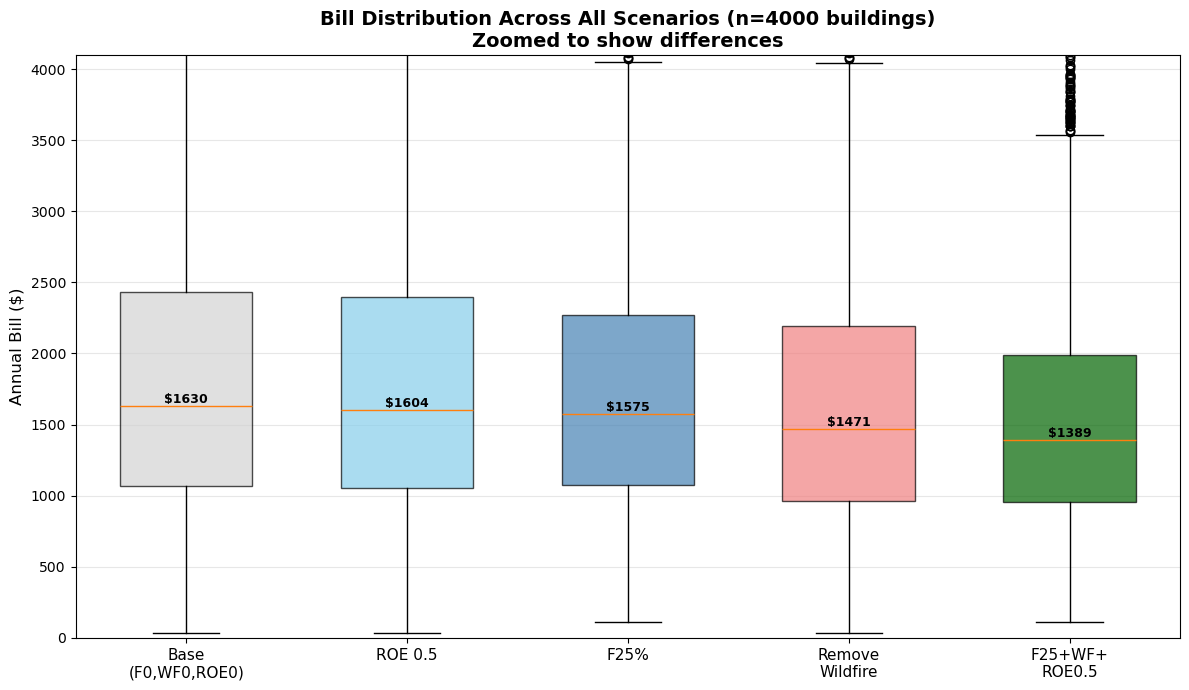

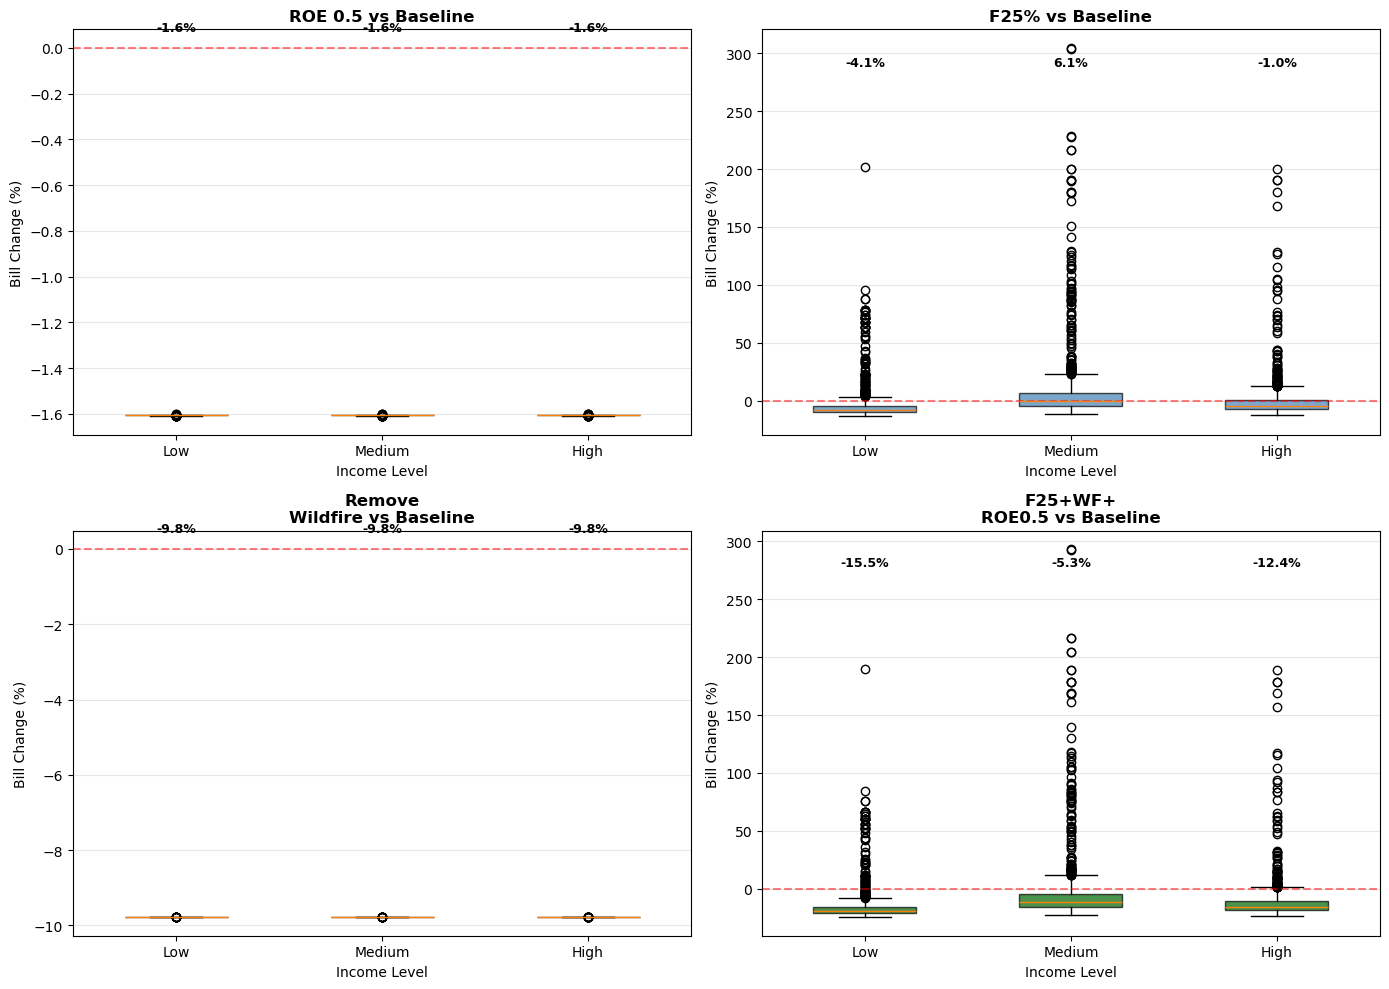

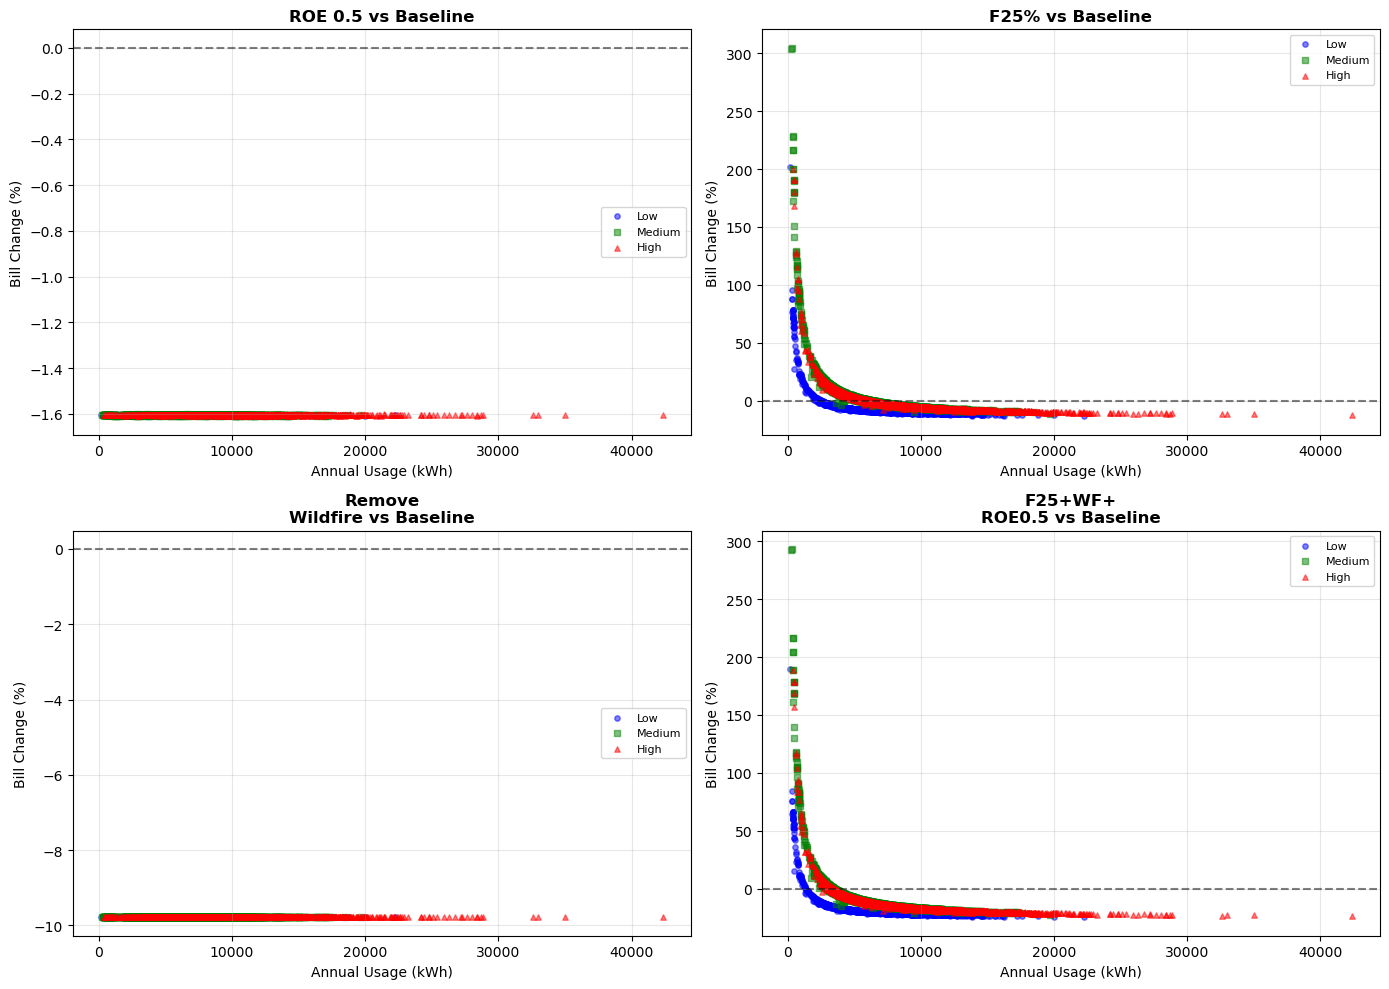

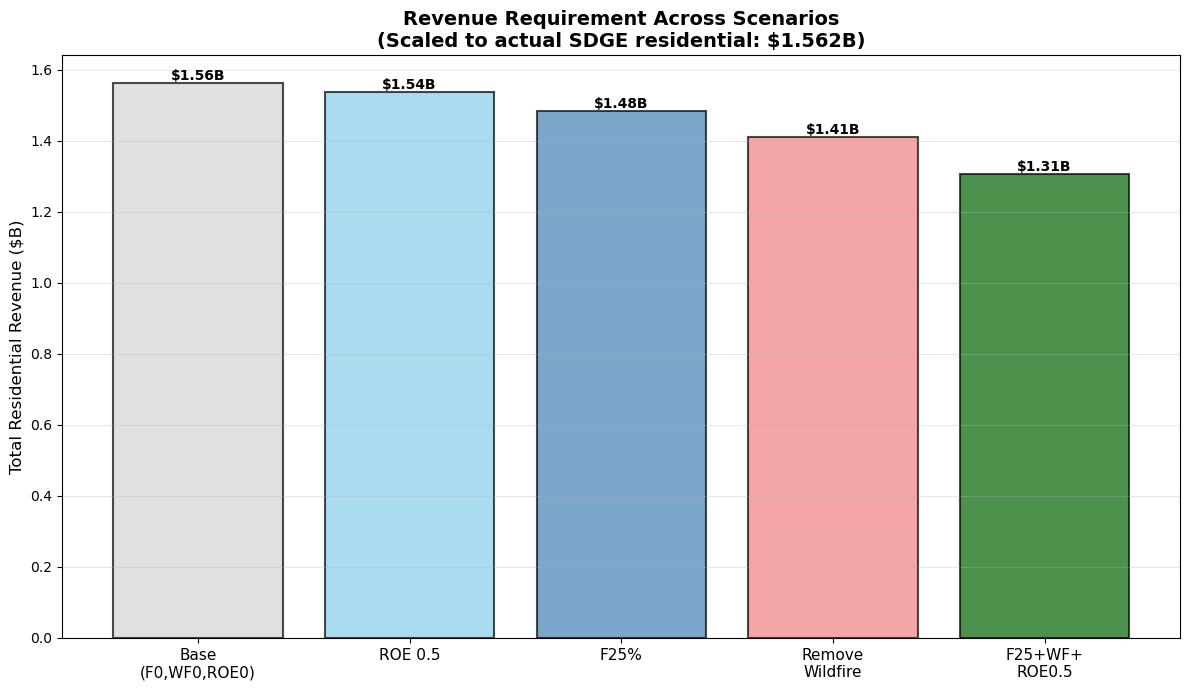

In [11]:
# final_analysis_v2.py - 5 Scenario Comparison (new_F0_WF0_ROE0 as baseline)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('baseline_bills_Feb6.csv')
scaling_factor = 1_323_612 / len(df)

# Define 5 scenarios with new baseline
SCENARIOS = {
    1: {'col': 'new_F0_WF0_ROE0_bill',    'label': 'Base\n(F0,WF0,ROE0)',   'color': 'lightgray'},
    2: {'col': 'new_F0_WF0_ROE0.5_bill',  'label': 'ROE 0.5',              'color': 'skyblue'},
    3: {'col': 'new_F25_WF0_ROE0_bill',   'label': 'F25%',                 'color': 'steelblue'},
    4: {'col': 'new_F0_WF1_ROE0_bill',    'label': 'Remove\nWildfire',     'color': 'lightcoral'},
    5: {'col': 'new_F25_WF1_ROE0.5_bill', 'label': 'F25+WF+\nROE0.5',     'color': 'darkgreen'}
}

baseline_col = SCENARIOS[1]['col']
baseline_mean = df[baseline_col].mean()

# Calculate changes from baseline for scenarios 2-5
for i in range(2, 6):
    col = SCENARIOS[i]['col']
    df[f'pct_change_{i}'] = 100 * (df[col] - df[baseline_col]) / df[baseline_col]
    df[f'dollar_change_{i}'] = df[col] - df[baseline_col]

# ============================================================================
# FIGURE 1: Box plot - ZOOMED to show differences
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

bill_data = [df[SCENARIOS[i]['col']].values for i in range(1, 6)]
labels = [SCENARIOS[i]['label'] for i in range(1, 6)]
colors = [SCENARIOS[i]['color'] for i in range(1, 6)]

positions = np.arange(len(labels))
bp = ax.boxplot(bill_data, positions=positions, widths=0.6, patch_artist=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# ZOOM IN on the interquartile range
all_data = np.concatenate(bill_data)
q1, q3 = np.percentile(all_data, [25, 75])
iqr = q3 - q1
y_min = max(0, q1 - 1.5*iqr)
y_max = q3 + 1.5*iqr

ax.set_ylim(y_min, y_max)

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Annual Bill ($)', fontsize=12)
ax.set_title('Bill Distribution Across All Scenarios (n=4000 buildings)\nZoomed to show differences', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add median values as text
for i, data in enumerate(bill_data):
    median = np.median(data)
    ax.text(i, median, f'${median:.0f}', 
           ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_all_scenarios_boxplot.png', dpi=150, bbox_inches='tight')
print("Saved: fig1_all_scenarios_boxplot.png")

# ============================================================================
# FIGURE 2: % Bill changes by income (4 subplots - scenarios 2-5)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, scenario_num in enumerate(range(2, 6)):
    ax = axes[idx]
    col = f'pct_change_{scenario_num}'
    
    data = [df[df['income'] == inc][col].values for inc in ['low', 'medium', 'high']]
    positions = [1, 2, 3]
    
    bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(SCENARIOS[scenario_num]['color'])
        patch.set_alpha(0.7)
    
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xticklabels(['Low', 'Medium', 'High'])
    ax.set_xlabel('Income Level')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{SCENARIOS[scenario_num]["label"]} vs Baseline', 
                 fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean values as text
    for i, income in enumerate(['low', 'medium', 'high']):
        mean_val = df[df['income'] == income][col].mean()
        ax.text(i+1, ax.get_ylim()[1]*0.9, f'{mean_val:.1f}%', 
               ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_pct_change_by_income.png', dpi=150, bbox_inches='tight')
print("Saved: fig2_pct_change_by_income.png")

# ============================================================================
# FIGURE 3: % Bill changes by consumption (4 subplots)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, scenario_num in enumerate(range(2, 6)):
    ax = axes[idx]
    col = f'pct_change_{scenario_num}'
    
    # Color by income
    for income, color, marker in [('low', 'blue', 'o'), 
                                   ('medium', 'green', 's'), 
                                   ('high', 'red', '^')]:
        df_inc = df[df['income'] == income]
        ax.scatter(df_inc['annual_kwh_prescaling'], df_inc[col], 
                  alpha=0.5, s=15, c=color, marker=marker, label=income.capitalize())
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Annual Usage (kWh)')
    ax.set_ylabel('Bill Change (%)')
    ax.set_title(f'{SCENARIOS[scenario_num]["label"]} vs Baseline', 
                 fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_pct_change_by_consumption.png', dpi=150, bbox_inches='tight')
print("Saved: fig3_pct_change_by_consumption.png")

# ============================================================================
# FIGURE 4: Revenue requirement across scenarios (CORRECTED SCALE)
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Calculate actual revenues
revenues_calculated = []
for i in range(1, 6):
    col = SCENARIOS[i]['col']
    total_rev = df[col].sum() * scaling_factor / 1e9
    revenues_calculated.append(total_rev)

# Scale to actual SDGE residential revenue
TARGET_REVENUE = 1.562  # $1.562B actual
baseline_calculated = revenues_calculated[0]
scaling_correction = TARGET_REVENUE / baseline_calculated

revenues_corrected = [rev * scaling_correction for rev in revenues_calculated]

bars = ax.bar(range(5), revenues_corrected, color=[SCENARIOS[i]['color'] for i in range(1, 6)],
              alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xticks(range(5))
ax.set_xticklabels([SCENARIOS[i]['label'] for i in range(1, 6)], fontsize=11)
ax.set_ylabel('Total Residential Revenue ($B)', fontsize=12)
ax.set_title('Revenue Requirement Across Scenarios\n(Scaled to actual SDGE residential: $1.562B)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, rev) in enumerate(zip(bars, revenues_corrected)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${rev:.2f}B',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_revenue_requirements.png', dpi=150, bbox_inches='tight')
print("Saved: fig4_revenue_requirements.png")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS (new_F0_WF0_ROE0 as Baseline)")
print("="*80)

print("\n1. MEAN ANNUAL BILLS:")
for i in range(1, 6):
    col = SCENARIOS[i]['col']
    mean_bill = df[col].mean()
    pct_vs_baseline = (mean_bill - baseline_mean) / baseline_mean * 100 if i > 1 else 0
    print(f"   {SCENARIOS[i]['label']:20s}: ${mean_bill:6.0f} ({pct_vs_baseline:+6.1f}%)")

print("\n2. TOTAL REVENUE (scaled to full SDGE):")
for i in range(1, 6):
    col = SCENARIOS[i]['col']
    total_rev = df[col].sum() * scaling_factor / 1e9
    print(f"   {SCENARIOS[i]['label']:20s}: ${total_rev:.3f}B")

print("\n3. BILL CHANGES BY INCOME (mean % change from baseline):")
for scenario_num in range(2, 6):
    print(f"\n   {SCENARIOS[scenario_num]['label']}:")
    for income in ['low', 'medium', 'high']:
        col = f'pct_change_{scenario_num}'
        mean_pct = df[df['income'] == income][col].mean()
        median_pct = df[df['income'] == income][col].median()
        print(f"      {income.capitalize():8s}: Mean {mean_pct:+6.1f}%  |  Median {median_pct:+6.1f}%")

print("\n" + "="*80)